# Loading required libraries

In [1]:
library(ggplot2)
library(patchwork)
library(scales)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(broom)
library(circlize)
library(survminer)
library(survival)
library(showtext)
library(svglite)
library(purrr)
source("../survival_analysis/utils/helpers.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reve

## Figures and Files Setup

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_4"

# Color palettes

In [4]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2-like macrophages" = "#66A61E",
  "M1-like macrophages" = "#00557F",
  "M1/M2-like macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)


# cluster_palette <- c(

#   "Tumor_bulk" = "#00B3A4",

#   "Lymphoid_T" = "#D62828",

#   "Myeloid_granulocytic" = "#6A00F4",

#   "Tumor_myeloid" = "#80ED99",

#   "Lymphoid_B" = "#FFB703",

#   "Lymphatic_immune" = "#1F78B4",

#   "Vascular/Endothelial" = "#00BFC4",

#   "Stromal_fibroblasts" = "#B39DDB",

#   "Stromal_NFC" = "#6C757D",

#   "Epithelial_adjacent" = "#C9B29B",

#   "Tumor_NFC" = "#CED4DA",

#   "Lymphoid_enriched" = "#E76F51"
# )


cluster_palette <- c(

  "Tumor_bulk" = "#00B3A4",

  "Granulocytic_suppressive" = "#6A00F4",

  "Tumor_myeloid_enriched" = "#80ED99",

  "Lymphatic_immune" = "#1F78B4",

  "Vascular" = "#00BFC4",

  "Stromal_perivascular" = "#B39DDB",

  "Unknown_stromal" = "#6C757D",

  "Epithelial_adjacent" = "#C9B29B",

  "Unknown_tumor" = "#CED4DA",

  "TLS_like" = "#E76F51",

  "Lymphoid_T_enriched" = "#D62828"
)


# Load the required data

In [5]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1-like macrophages", "M2-like macrophages", "M1/M2-like macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
#niches df 
niches_df <- read.csv(file.path(data_dir, "niches_df.csv"))

In [7]:
#niches enrichment and pvalues
enr_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment.csv"))
pvalue_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"))

Rows: 19 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (11): Epithelial_adjacent, Granulocytic_suppressive, Lymphatic_immune, L...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 19 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (11): Epithelial_adjacent, Granulocytic_suppressive, Lymphatic_immune, L...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Abdomen")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Abdomen"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

In [9]:
celltype_percentage_exp <- read.csv(paste0(data_dir, "/celltype_percentage_exp.csv")) %>%
   mutate(patient_exp = factor(patient_exp, levels = patient_exp_order),
          patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
   arrange(patient_exp, patient_ID, cell_category)

celltype_percentage_patient <- read.csv(paste0(data_dir, "/celltype_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
arrange(patient_ID, cell_category)

cellparent_percentage_patient <- read.csv(paste0(data_dir, "/cellparent_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
arrange(patient_ID, cell_category_parent)

cellgroup_percentage_patient <- read.csv(paste0(data_dir, "/cellgroup_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order),
    cell_category_simplified = factor(cell_category_simplified, levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")))

In [10]:
#reading summary tbl as RDS
summary_tbl <- readRDS(paste0(data_dir, "/summary_tbl.rds"))

# Figure 4 - B

In [9]:
cluster_composition <- niches_df %>%
    group_by(neighborhood, cell_category) %>%
    summarise(n_cells = n()) %>%
    ungroup() %>%
    group_by(neighborhood) %>%
    mutate("total_n" = sum(n_cells)) %>%
    ungroup() %>%
    mutate("percentage" = (n_cells / total_n) * 100) %>%
    select(!total_n)
cluster_composition

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by neighborhood and cell_category.
ℹ Output is grouped by neighborhood.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(neighborhood, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


neighborhood,cell_category,n_cells,percentage
<chr>,<chr>,<int>,<dbl>
Epithelial_adjacent,Actin+ cells,46,0.43220896
Epithelial_adjacent,B cells,10,0.09395847
Epithelial_adjacent,CD4+ T cells,56,0.52616743
Epithelial_adjacent,CD8+ T cells,178,1.67246077
Epithelial_adjacent,DCs,25,0.23489618
Epithelial_adjacent,Endothelial cells,88,0.82683454
Epithelial_adjacent,Epithelial cells,8163,76.69829935
Epithelial_adjacent,Granulocytes,334,3.13821291
Epithelial_adjacent,Lymphatic endothelial cells,148,1.39058536


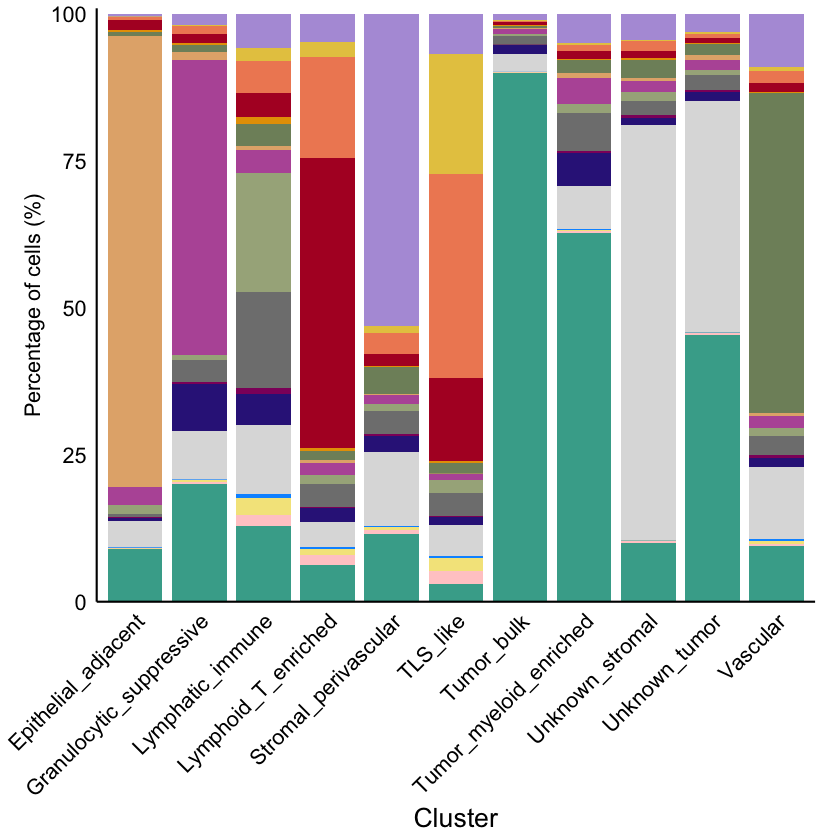

In [10]:
shared_margin <- margin(t = 5, r = 15, b = 5, l = 15)

p_cluster <- ggplot(
  cluster_composition,
  aes(x = neighborhood, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cluster",
    y = "Percentage of cells (%)",
    fill = "Cell type"
  ) +
  scale_y_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial"),

    # restore y-axis text + title
    axis.text.y  = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13),

    # rotate x labels
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank(),
    plot.margin = shared_margin
  )

p_cluster

showtext_opts(dpi = 300)
ggsave(
  filename = file.path(results_dir, "cluster_composition_barplot.png"),
  plot = p_cluster,
  width = 7,
  height = 6,
  dpi = 300,
  bg = "white"
)

In [11]:
p_long <- pvalue_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "pvalue"
  )

enr_long <- enr_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "enrichment"
  )

df_plot <- enr_long %>%
  left_join(p_long, by = c("cell_category", "neighborhood")) %>%
  mutate(
    neighborhood = factor(neighborhood, levels = sort(unique(neighborhood))),
    cell_category = factor(cell_category)
  )

df_plot_filt <- df_plot %>%
  filter(enrichment > 0, pvalue < 0.01) %>%
  mutate(
    enrichment_cap = pmin(enrichment, 4),
    neglog10_p = -log10(pvalue)
  )

p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) + 
  scale_size_area(
    max_size = 7,
    breaks = c(1, 2, 3, 4),
    name = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
  low = "#fcbba1",
  high = "#99000d",
  name = expression(-log[10] * "(p-value)"),
  limits = c(2, 2.4),
  breaks = c(2.0, 2.2, 2.4)
) +
  labs(
    x = "Cell type",
    y = "Cellular neighborhood"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(colour = "black", size = 13),
    panel.grid.major = element_line(linewidth = 0.3),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 13, colour = "black"),
    axis.text.y = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.title.x = element_text(size = 13, colour = "black", margin = margin(t = 1)),
    axis.line = element_line(color = "black")
  )

ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot = p,
  width = 10,
  height = 6,
  device = cairo_pdf,
  dpi = 300,
  bg = "white"
)

In [12]:
# ── Niche color strip ─────────────────────────────────────────────────────────
niche_strip <- ggplot(
  data.frame(neighborhood = factor(levels(df_plot_filt$neighborhood),
                                   levels = levels(df_plot_filt$neighborhood))),
  aes(x = 1, y = neighborhood, fill = neighborhood)
) +
  geom_tile() +
  scale_fill_manual(values = cluster_palette) +
  scale_y_discrete(limits = rev) +
  labs(y = "Cellular neighborhood") +
  theme_void() +
  theme(
    legend.position = "none",
    axis.text.y     = element_text(size = 13, colour = "black", hjust = 0),
    axis.title.y    = element_text(size = 13, colour = "black", angle = 90, margin = margin(r = 10))
  )

# ── Main dot plot ─────────────────────────────────────────────────────────────
p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_area(
    max_size = 7,
    breaks   = c(1, 2, 3, 4),
    name     = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
    low    = "#fcbba1",
    high   = "#99000d",
    name   = expression(-log[10] * "(p-value)"),
    limits = c(2, 2.4),
    breaks = c(2.0, 2.2, 2.4)
  ) +
  labs(
    x = "Cell type",
    y = NULL
  ) +
  theme_minimal(base_size = 13) +
    theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_blank(),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
  )

# ── Combine: strip on the left with names, dot plot on the right ──────────────
combined <- niche_strip + p +
  plot_layout(widths = c(0.05, 1))

ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot     = combined,
  width    = 12,
  height   = 6,
  device   = "pdf",
  dpi      = 300,
  bg       = "white"
)

In [13]:
# ── Niche color strip ─────────────────────────────────────────────────────────
niche_strip <- ggplot(
  data.frame(neighborhood = factor(levels(df_plot_filt$neighborhood),
                                   levels = levels(df_plot_filt$neighborhood))),
  aes(x = 1, y = neighborhood, fill = neighborhood)
) +
  geom_tile() +
  scale_fill_manual(values = cluster_palette) +
  scale_y_discrete(limits = rev) +
  labs(y = "Cellular neighborhood") +
  theme_void() +
  theme(
    legend.position = "none",
    axis.text.y     = element_text(size = 13, colour = "black", hjust = 0),
    axis.title.y    = element_text(size = 13, colour = "black", angle = 90, margin = margin(r = 10))
  )

# ── Main dot plot ─────────────────────────────────────────────────────────────
p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_area(
    max_size = 7,
    breaks   = c(1, 2, 3, 4),
    name     = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
    low    = "#fcbba1",
    high   = "#99000d",
    name   = expression(-log[10] * "(p-value)"),
    limits = c(2, 2.4),
    breaks = c(2.0, 2.2, 2.4)
  ) +
  labs(
    x = "Cell type",
    y = NULL
  ) +
  theme_minimal(base_size = 13) +
    theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_blank(),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
  )

# ── Combine: strip on the left with names, dot plot on the right ──────────────
combined <- niche_strip + p +
  plot_layout(widths = c(0.05, 1))

ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.svg"),
  plot     = combined,
  width    = 12,
  height   = 6,
  device   = svglite,
  dpi      = 300,
  bg       = "white"
)

# A - Figure 5

In [15]:
#percentage of clusters per patient
patient_clusters <- niches_df %>%
  group_by(patient_ID, neighborhood) %>%
  summarise(n_cells = n()) %>%
  ungroup() %>%
  group_by(patient_ID) %>%
  mutate(percentage = (n_cells / sum(n_cells)) * 100) %>%
  ungroup() %>%
  mutate("patient_ID" = factor(patient_ID, levels = patient_ID_order)) %>%
  arrange(patient_ID)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and neighborhood.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, neighborhood))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


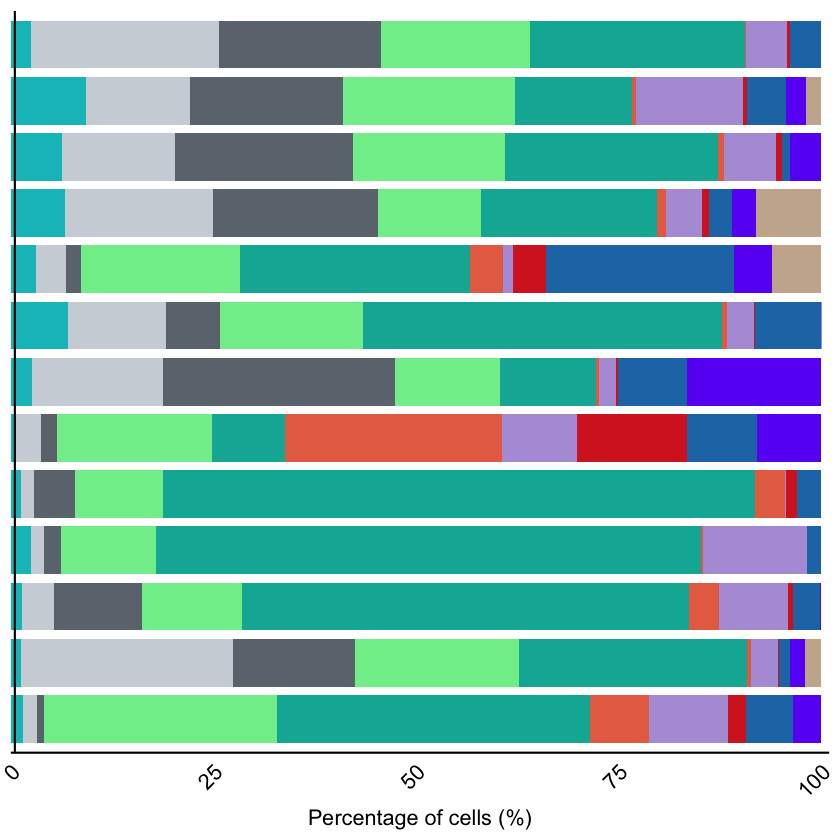

In [17]:
p_patient <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()
  )
p_patient

ggsave(
  filename = file.path(results_dir, "patient_cluster.pdf"),
  plot = p_patient,
  width = 5,
  height = 5,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

In [18]:
#save the legend 

p_patient_legend <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "right",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()  
    )
p_patient_legend_only <- get_legend(p_patient_legend)
ggsave(
  filename = file.path(results_dir, "patient_cluster_legend.pdf"),
  plot = p_patient_legend_only,
  width = 3,
  height = 4.5,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

#one on the bottom 
#save the legend 

p_patient_legend <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()  
    )
p_patient_legend_only <- get_legend(p_patient_legend)
ggsave(
  filename = file.path(results_dir, "patient_cluster_legend_bottom.pdf"),
  plot = p_patient_legend_only,
  width = 10,
  height = 1,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


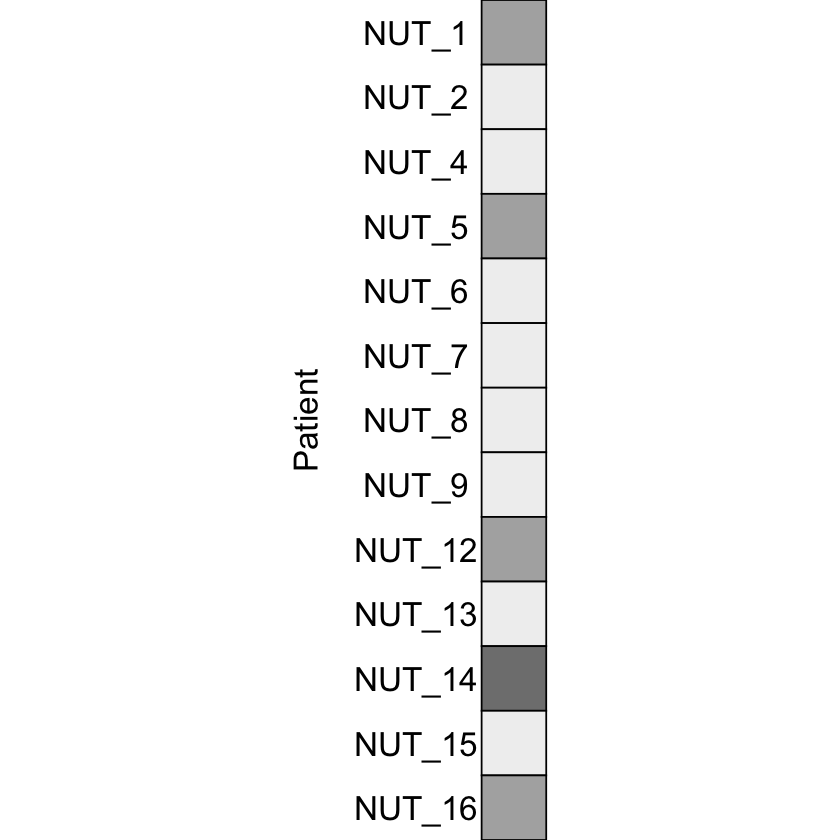

In [19]:
tumor_site_df <- celltype_metadata %>% 
    select(patient_ID, tumor_site) %>%
    distinct() 

tumor_site_plot <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
         legend.position = "none",
)
  tumor_site_plot

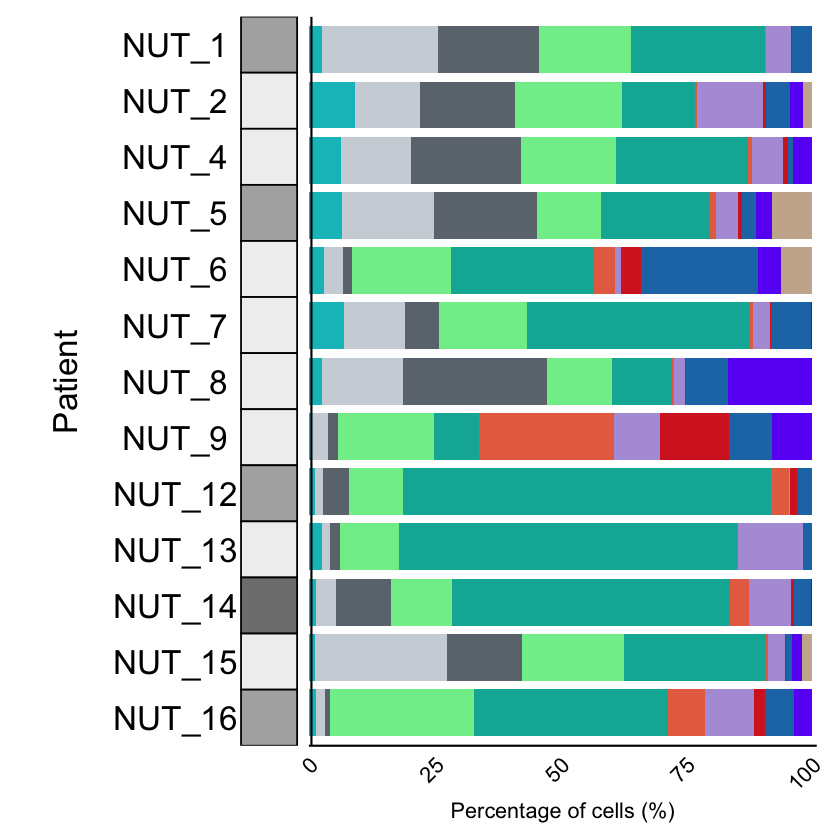

In [20]:
final_plot <- wrap_plots(
  tumor_site_plot, plot_spacer(), p_patient,
  ncol = 3,
  widths = c(1,-0.5,4)
) & theme(plot.margin = margin(t=5, r=7, b=5, l=5))
final_plot
ggsave(
  filename = file.path(results_dir, "clusters_per_patient_tissue.pdf"),
  plot = final_plot,
  width = 8,
  height = 6,
  dpi = 300
)


# C - Figure 4

In [22]:
plot_niches <- function(df, title = NULL,
                        color_var = "neighborhood",
                        palette = cluster_palette,
                        bg_color = "#D9D9D9", bg_alpha = 1, pt_size_fg = 1.5) {

  ggplot() +
    geom_point(
      data = df,
      aes(x = `Cell.Center.X`, y = `Cell.Center.Y`, color = .data[[color_var]]),
      alpha = 0.95,
      size  = pt_size_fg
    ) +
    scale_color_manual(
      values = palette,
      drop   = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title  = element_blank(),
      plot.title    = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}

In [63]:
plot_niches <- function(df, title = NULL,
                        color_var = "neighborhood",
                        palette = cluster_palette,
                        highlight = NULL,       # vector of neighborhoods/celltypes to highlight
                        bg_color = "#D9D9D9", bg_alpha = 1, pt_size_fg = 1.5) {

  if (!is.null(highlight)) {
    df_fg <- df %>% filter(.data[[color_var]] %in% highlight)
    df_bg <- df %>% filter(!.data[[color_var]] %in% highlight)
  } else {
    df_fg <- df
    df_bg <- NULL
  }

  p <- ggplot()

  # grey background points if highlight is used
  if (!is.null(df_bg) && nrow(df_bg) > 0) {
    p <- p + geom_point(
      data  = df_bg,
      aes(x = `Cell.Center.X`, y = `Cell.Center.Y`),
      color = bg_color,
      alpha = bg_alpha,
      size  = pt_size_fg
    )
  }

  # foreground colored points
  p <- p + geom_point(
    data = df_fg,
    aes(x = `Cell.Center.X`, y = `Cell.Center.Y`, color = .data[[color_var]]),
    alpha = 0.95,
    size  = pt_size_fg
  ) +
  scale_color_manual(
    values = palette,
    drop   = TRUE
  ) +
  coord_equal() +
  theme_void() +
  theme(
    legend.title    = element_blank(),
    plot.title      = element_text(hjust = 0.5),
    legend.position = "none"
  ) +
  ggtitle(title) +
  scale_y_reverse()

  p
}

# F

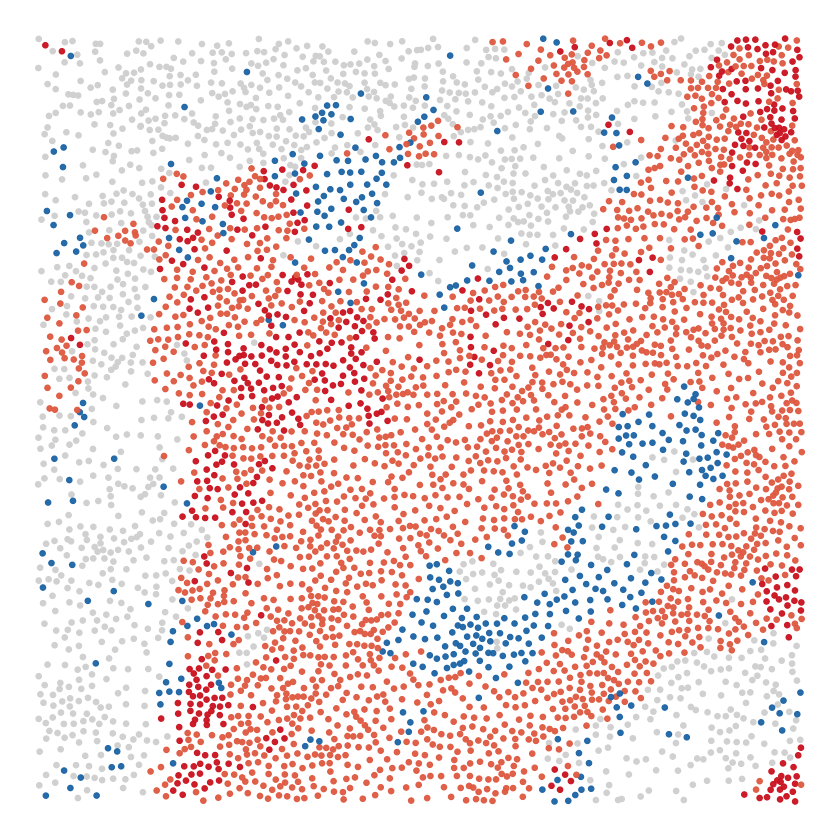

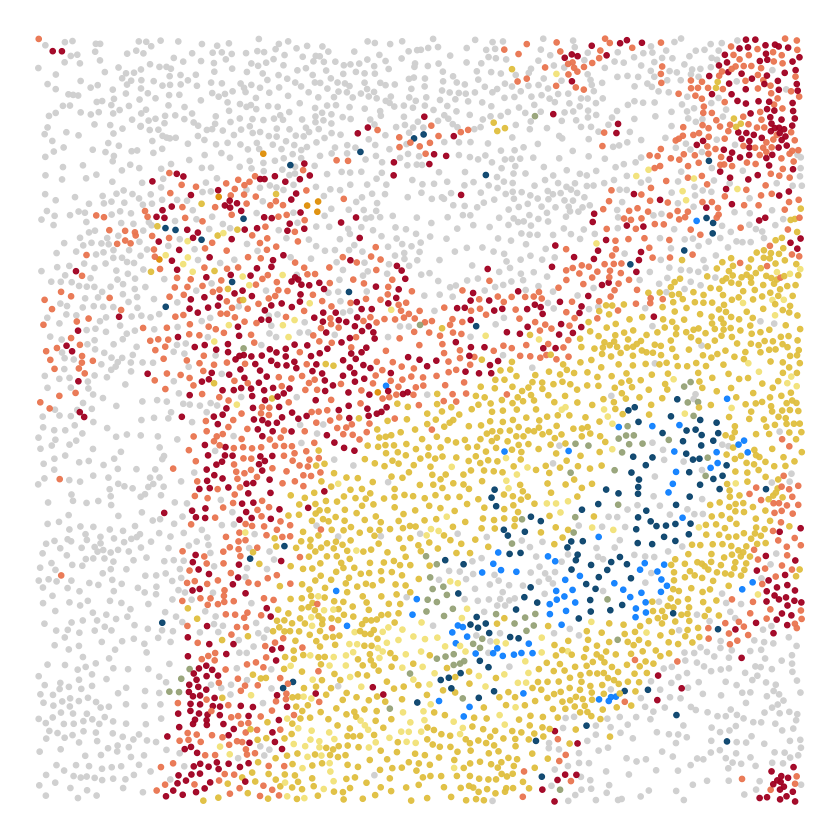

In [116]:
exp <- "NUT_9_ROI4"
x = 6200
y = 2700
df <- niches_df %>%
    filter(Cell.Center.X > x & Cell.Center.X < x + 4000 & Cell.Center.Y > y & Cell.Center.Y < y + 4000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Lymphoid_T_enriched", "TLS_like", "Lymphatic_immune"))
  p



ggsave(filename = paste0(results_dir, "/NUT_9_ROI4_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")

p <- plot_niches(color_var = "cell_category", palette = full_palette,
highlight = c("CD4+ T cells", "CD8+ T cells", "NK cells", "B cells", "PCs", "M1 macrophages", "Lymphatic endothelial cells", "DCs"),
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_9_ROI4_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



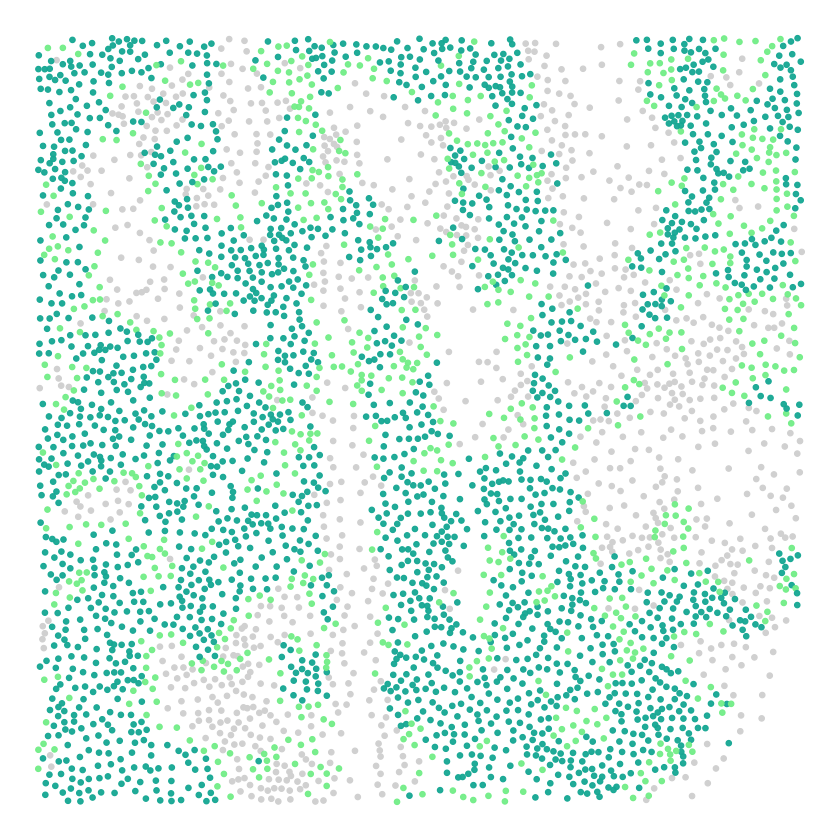

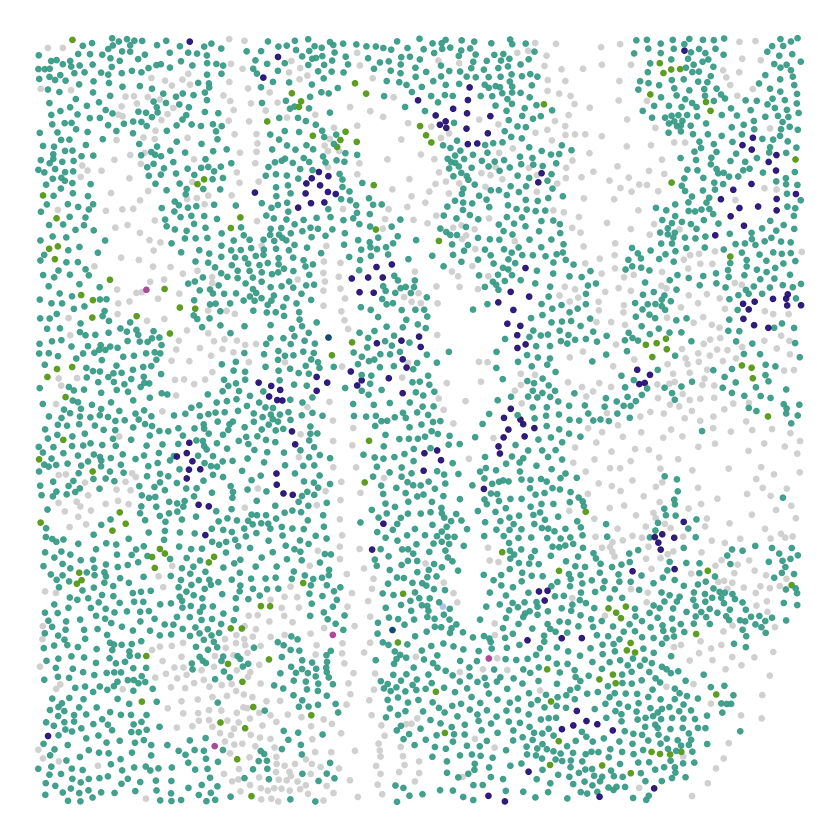

In [120]:
exp <- "NUT_7_ROI14"
x = 10000
y = 9000
df <- niches_df %>%
    filter(Cell.Center.X > x & Cell.Center.X < x + 4000 & Cell.Center.Y > y & Cell.Center.Y < y + 4000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Tumor_bulk", "Tumor_myeloid_enriched"))
  p



ggsave(filename = paste0(results_dir, "/NUT_7_ROI14_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")
       

p <- plot_niches(color_var = "cell_category", palette = full_palette,
highlight = c("Tumor cells", "M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "Granulocytes", "MDSCs"),
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_7_ROI14_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



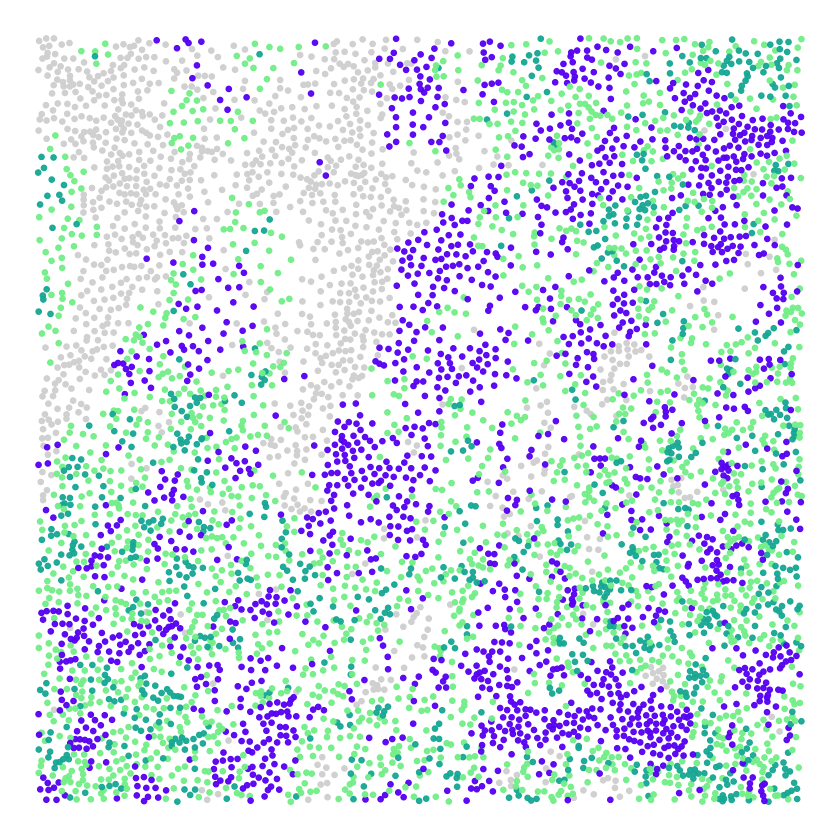

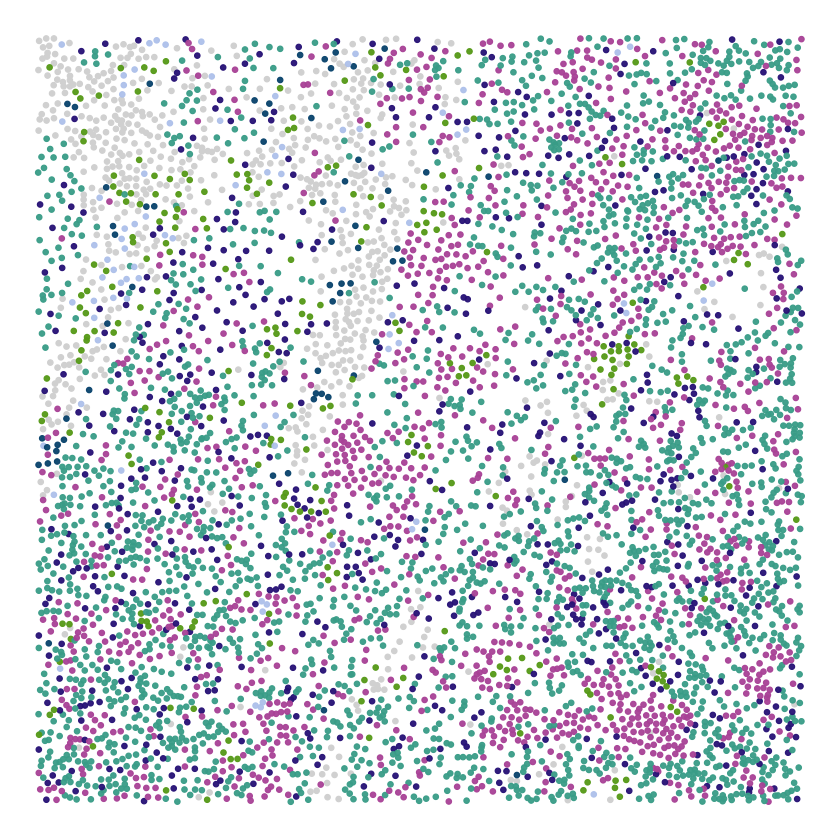

In [65]:
exp <- "NUT_9_ROI3"
x = 4000
y = 500
df <- niches_df %>%
    filter(Cell.Center.X > x & Cell.Center.X < x + 4000 & Cell.Center.Y > y & Cell.Center.Y < y + 4000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Tumor_bulk", "Tumor_myeloid_enriched", "Granulocytic_suppressive"))
  p



ggsave(filename = paste0(results_dir, "/NUT_9_ROI3_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")
       

p <- plot_niches(color_var = "cell_category", palette = full_palette,
highlight = c("Tumor cells", "M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "Granulocytes", "MDSCs"),
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_9_ROI3_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



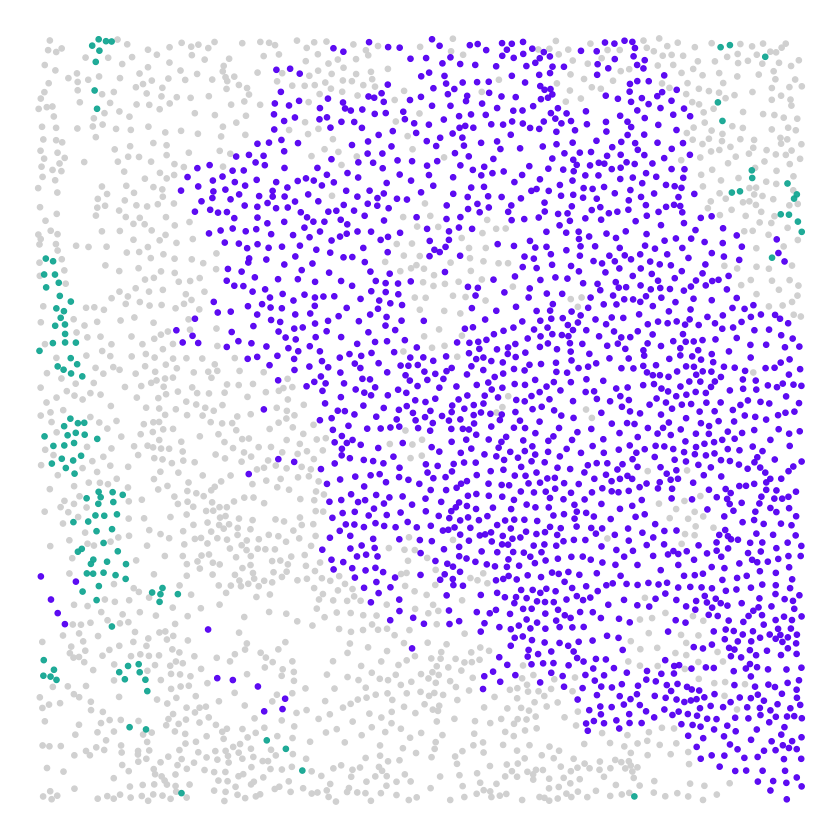

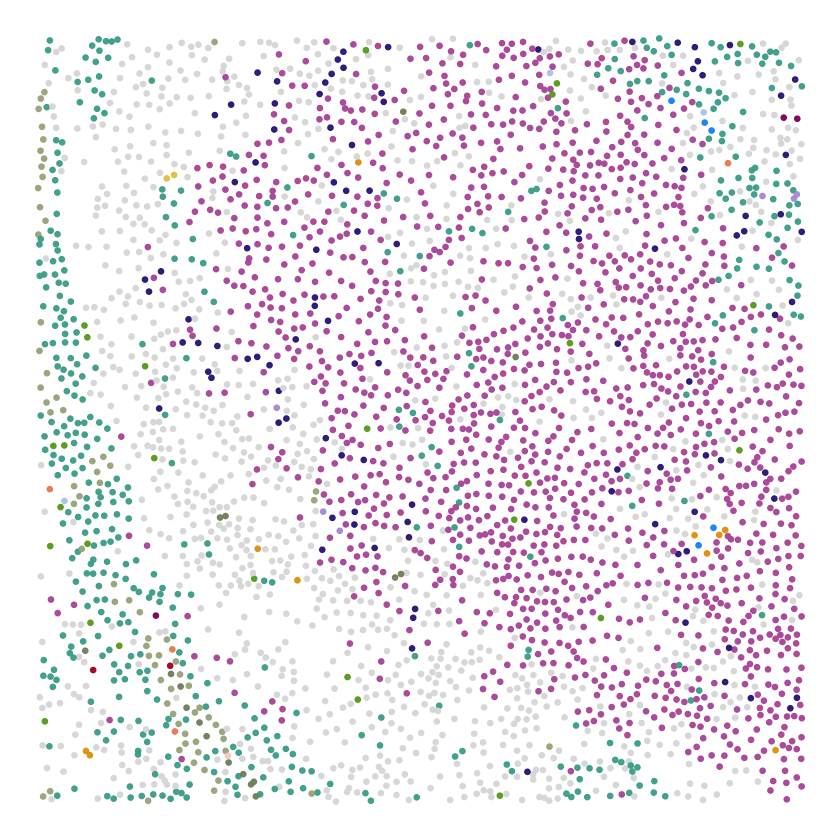

In [66]:
exp <- "NUT_8_ROI17"
x = 4500
y = 1000
df <- niches_df %>%
    filter(Cell.Center.X > x & Cell.Center.X < x + 4000 & Cell.Center.Y > y & Cell.Center.Y < y + 4000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Granulocytic_suppressive", "Tumor_bulk"))
  p



ggsave(filename = paste0(results_dir, "/NUT_8_ROI17_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")

p <- plot_niches(color_var = "cell_category", palette = full_palette,
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_8_ROI17_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



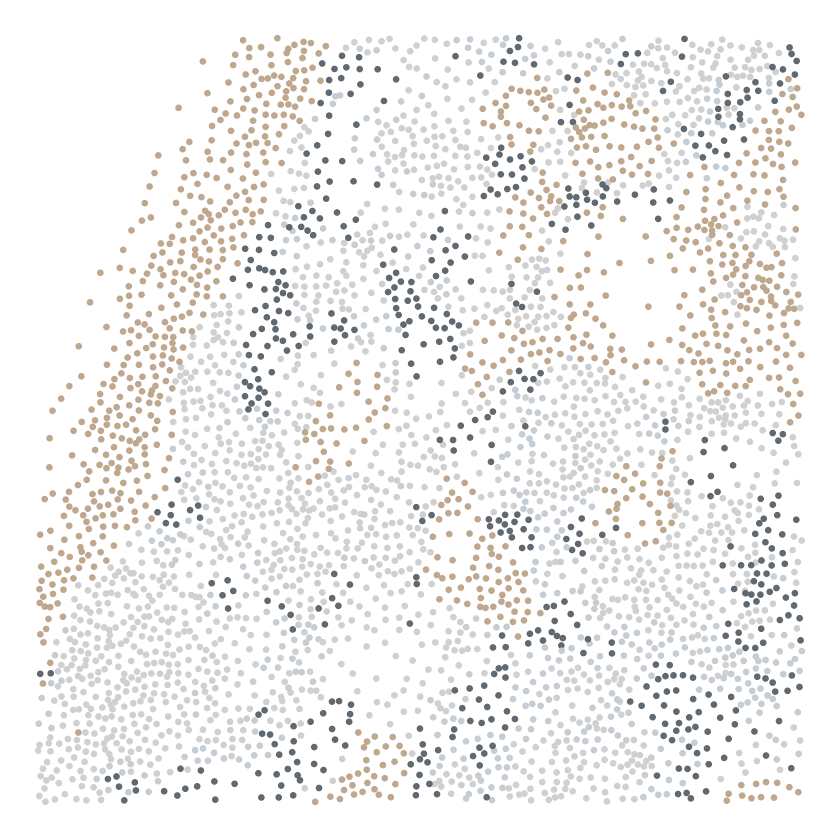

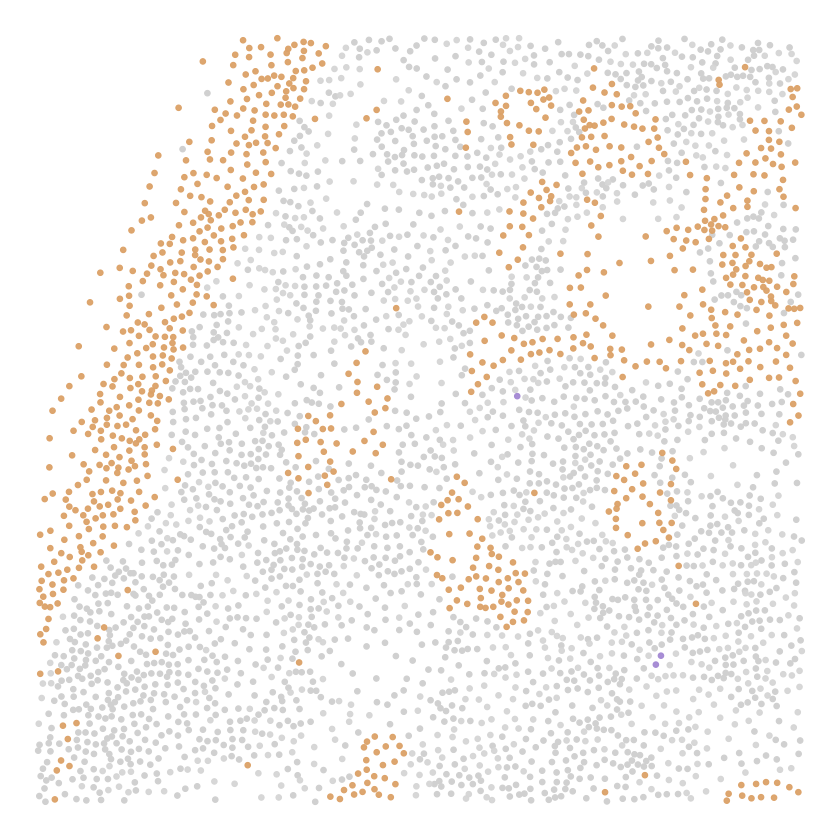

In [174]:
exp <- "NUT_5_ROI10"
x = 1000
y = 4000
df <- niches_df %>%
    filter(Cell.Center.X > x & Cell.Center.X < x + 4000 & Cell.Center.Y > y & Cell.Center.Y < y + 4000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Epithelial_adjacent", "Unknown_stromal","Unknown_tumor"))
  p



ggsave(filename = paste0(results_dir, "/NUT_5_ROI10_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")
       

p <- plot_niches(color_var = "cell_category", palette = full_palette,
highlight = c("Epithelial cells", "Actin+ cells", "NFC"),
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_5_ROI10_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



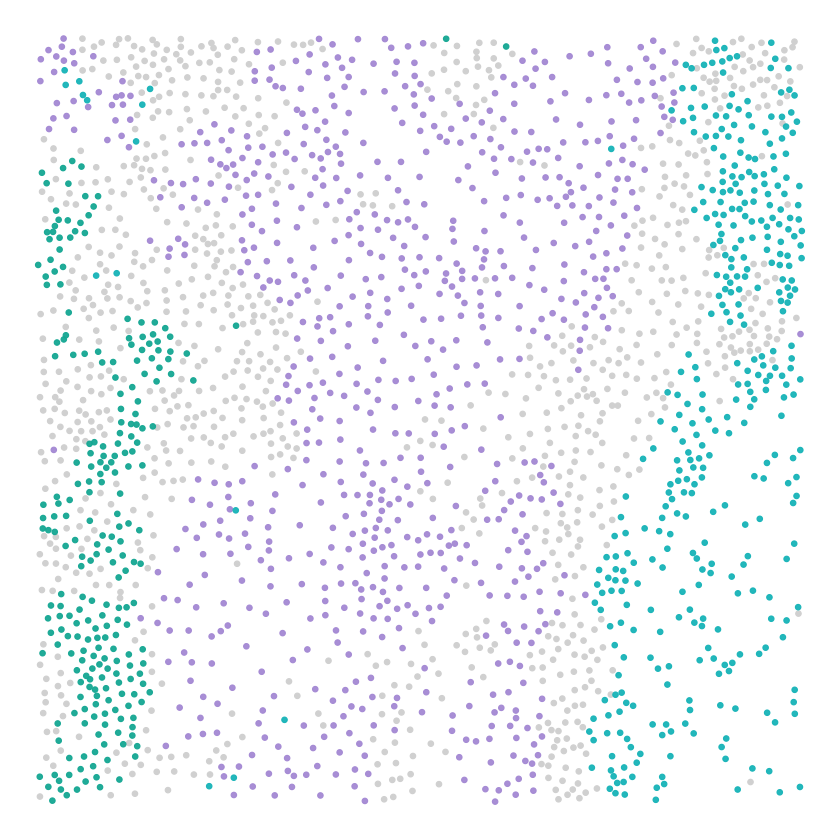

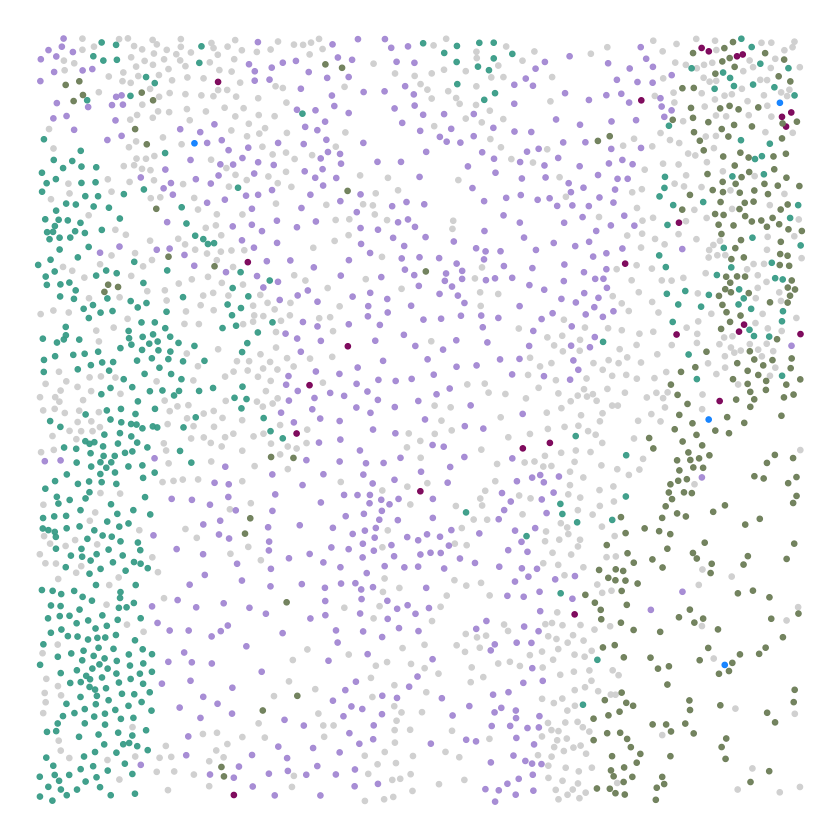

In [173]:
exp <- "NUT_7_ROI13"
x = 6000
y = 1000
df <- niches_df %>%
    filter(Cell.Center.X > x & Cell.Center.X < x + 4000 & Cell.Center.Y > y & Cell.Center.Y < y + 4000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Tumor_bulk", "Stromal_perivascular", "Vascular"))
  p



ggsave(filename = paste0(results_dir, "/NUT_7_ROI13_endo_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")
       

p <- plot_niches(color_var = "cell_category", palette = full_palette,
highlight = c("Tumor cells", "Actin+ cells", "Endothelial cells", "NK cells", "Mast cells"),
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_7_ROI13_endo_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



# Figure 5 - B

`height` was translated to `width`.
`height` was translated to `width`.


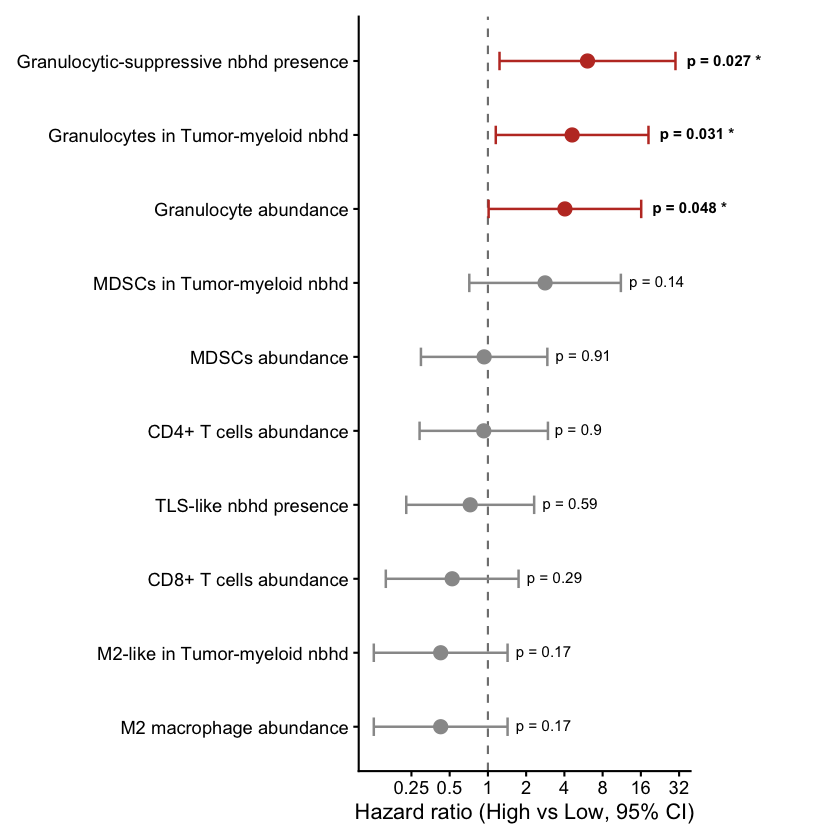

In [40]:
CI_CAP <- 50

forest_df <- summary_tbl %>%
  filter(!is.na(HR)) %>%
  arrange(HR) %>%
  mutate(
    variable = factor(variable, levels = variable),
    sig      = ifelse(p.value < 0.05, "p < 0.05", "n.s."),
    conf.high.disp = pmin(conf.high, CI_CAP),
    capped   = conf.high > CI_CAP,
    p_label  = ifelse(p.value < 0.05,
                      paste0("bold('p = ", signif(p.value, 2), " *')"),
                      paste0("'p = ", signif(p.value, 2), "'"))
  )

forest <- ggplot(forest_df, aes(x = HR, y = variable, colour = sig)) +
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey50", linewidth = 0.6) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high.disp),
                 height = 0.25, linewidth = 0.7) +
  geom_point(size = 3.5) +
  geom_text(aes(label = p_label, x = conf.high.disp),
            parse = TRUE, hjust = -0.15, size = 3.2, colour = "black") +
  scale_colour_manual(values = c("p < 0.05" = "#C0392B", "n.s." = "grey60"), name = NULL) +
  scale_x_log10(breaks = c(0.25,0.5,1,2,4,8,16,32),
                labels = c("0.25","0.5","1","2","4","8","16","32")) +
  coord_cartesian(clip = "off") +
  labs(x = "Hazard ratio (High vs Low, 95% CI)", y = NULL) +
   theme_classic(base_size = 13) +
  theme(legend.position = "none",
        axis.text.y  = element_text(size = 11, colour = "black"),
        axis.text.x  = element_text(size = 11, colour = "black"),
        plot.margin  = margin(10, 90, 10, 10),
        plot.title   = element_text(size = 13, hjust = 0.5))
forest

ggsave(file.path(results_dir, "forest_univariable_survival_features_plain.pdf"),
       plot = forest, width = 8, height = 4.5, dpi = 300, bg = "white")

# Figure 5 - C

1. Abundance of Granulocytes (tissue-wide) HR=4.04  p=0.048  PH_p=0.735  (Low=6, High=7)
2. Abundance of Granulocytes in Tumor-myeloid niche HR=4.60  p=0.031  PH_p=0.422  (Low=6, High=7)
3. Presence of Granulocytic-suppressive niche HR=6.08  p=0.027  PH_p=0.636  (Absent=5, Present=8)


Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""


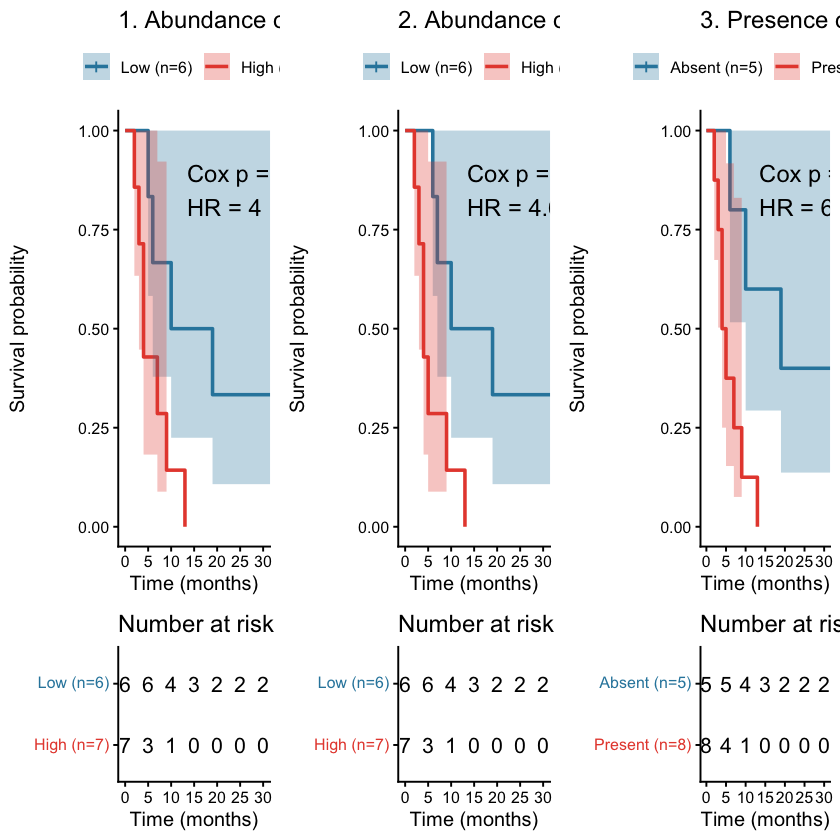

In [15]:
MIN_CELLS <- 10

surv_patient <- niches_df %>%
  distinct(patient_ID, survival_time_months) %>%
  left_join(survival_df %>% distinct(patient_ID, event), by = "patient_ID")

# ---- builders (from your existing code) ----
pct_patient <- function(df, celltype, niche = NULL) {
  d <- df; if (!is.null(niche)) d <- d %>% filter(neighborhood == niche)
  d %>%
    group_by(patient_ID, patient_exp) %>%
    summarise(n_total = n(),
              value = 100 * sum(cell_category == celltype) / n(), .groups = "drop") %>%
    filter(n_total >= MIN_CELLS) %>%
    group_by(patient_ID) %>% summarise(value = mean(value), .groups = "drop")
}
niche_pct_patient <- function(df, niche) {
  df %>%
    group_by(patient_ID, patient_exp) %>%
    summarise(n_total = n(),
              value = 100 * sum(neighborhood == niche) / n(), .groups = "drop") %>%
    filter(n_total >= MIN_CELLS) %>%
    group_by(patient_ID) %>% summarise(value = mean(value), .groups = "drop")
}

# ---- shared axis settings so the three panels are directly comparable ----
XLIM     <- c(0, 30)   # zoom past the lone 170-mo survivor; all events are < 50
BREAK_BY <- 5

make_km <- function(pat_df, label, split = "median", thresh = 1) {
  d <- pat_df %>% inner_join(surv_patient, by = "patient_ID") %>%
    filter(!is.na(value), !is.na(survival_time_months), !is.na(event))

  if (split == "median") {
    cut <- median(d$value, na.rm = TRUE); lv <- c("Low", "High")
    d <- d %>% mutate(grp = ifelse(value >= cut, "High", "Low"))
  } else if (split == "presence") {
    d <- d %>% mutate(grp = ifelse(value >= thresh, "Present", "Absent"))
    lv <- c("Absent", "Present")
  }
  d$grp <- factor(d$grp, levels = lv)
  tab <- table(d$grp)

  if (length(tab) < 2 || any(tab < 2)) {
    warning(label, ": degenerate split (", paste(names(tab), tab, collapse=", "),
            ") — consider changing split/threshold")
  }

  fit_cox <- coxph(Surv(survival_time_months, event) ~ grp, data = d)
  s  <- summary(fit_cox); cn <- rownames(s$coefficients)[1]
  cox_p  <- s$coefficients[cn, "Pr(>|z|)"]
  cox_hr <- s$coefficients[cn, "exp(coef)"]
  ph_p   <- tryCatch(cox.zph(fit_cox)$table[1, "p"], error = function(e) NA_real_)
  cat(sprintf("%-38s HR=%.2f  p=%.3f  PH_p=%.3f  (%s)\n",
              label, cox_hr, cox_p, ph_p,
              paste(names(tab), tab, sep="=", collapse=", ")))

  fit_km <- survfit(Surv(survival_time_months, event) ~ grp, data = d)

  ggsurvplot(fit_km, data = d,
    pval = paste0("Cox p = ", signif(cox_p, 2), "\nHR = ", signif(cox_hr, 2)),
    pval.coord = c(XLIM[2] * 0.45, 0.85), conf.int = TRUE,
    risk.table = TRUE, risk.table.height = 0.28,
    palette = c("#2E86AB", "#E74C3C"),
    xlab = "Time (months)", ylab = "Survival probability", title = label,
    legend.title = "", legend.labs = paste0(lv, " (n=", c(tab[[1]], tab[[2]]), ")"),
    xlim = XLIM, break.time.by = BREAK_BY,
    ggtheme = theme_classic(base_size = 12))
}

# ---- the 3 panels, in order of increasing spatial organization ----
p1 <- make_km(pct_patient(niches_df, "Granulocytes"),
              "1. Abundance of Granulocytes (tissue-wide)", split = "median")

p2 <- make_km(pct_patient(niches_df, "Granulocytes", "Tumor_myeloid_enriched"),
              "2. Abundance of Granulocytes in Tumor-myeloid niche", split = "median")
# NOTE: if panel 2 warns "degenerate split", the within-niche value is zero-inflated
# -> switch it to presence:  split = "presence", thresh = 1

p3 <- make_km(niche_pct_patient(niches_df, "Granulocytic_suppressive"),
              "3. Presence of Granulocytic-suppressive niche", split = "presence", thresh = 1)

# ---- assemble the three panels into one figure ----
combined <- arrange_ggsurvplots(
  list(p1, p2, p3),
  ncol = 3, nrow = 1,
  print = TRUE
)

# combined <- p1$plot + p2$plot + p3$plot

ggsave(file.path(results_dir, "KM_granulocyte_spatial_gradient_3panel.pdf"),
       plot = combined, width = 18, height = 6, dpi = 300, bg = "white")

# For Supplementary - Extra

CD4+ T cell abundance                  HR=0.93  p=0.899  PH_p=0.366  (Low=6, High=7)
CD8+ T cell abundance                  HR=0.52  p=0.292  PH_p=0.578  (Low=6, High=7)
MDSCs abundance (tissue-wide)          HR=0.93  p=0.907  PH_p=0.504  (Low=6, High=7)
MDSCs in Tumor-myeloid niche           HR=2.82  p=0.139  PH_p=0.349  (Low=6, High=7)
B cell abundance                       HR=2.39  p=0.217  PH_p=0.066  (Low=6, High=7)
TLS-like niche presence                HR=0.73  p=0.587  PH_p=0.204  (Absent=7, Present=6)


Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""


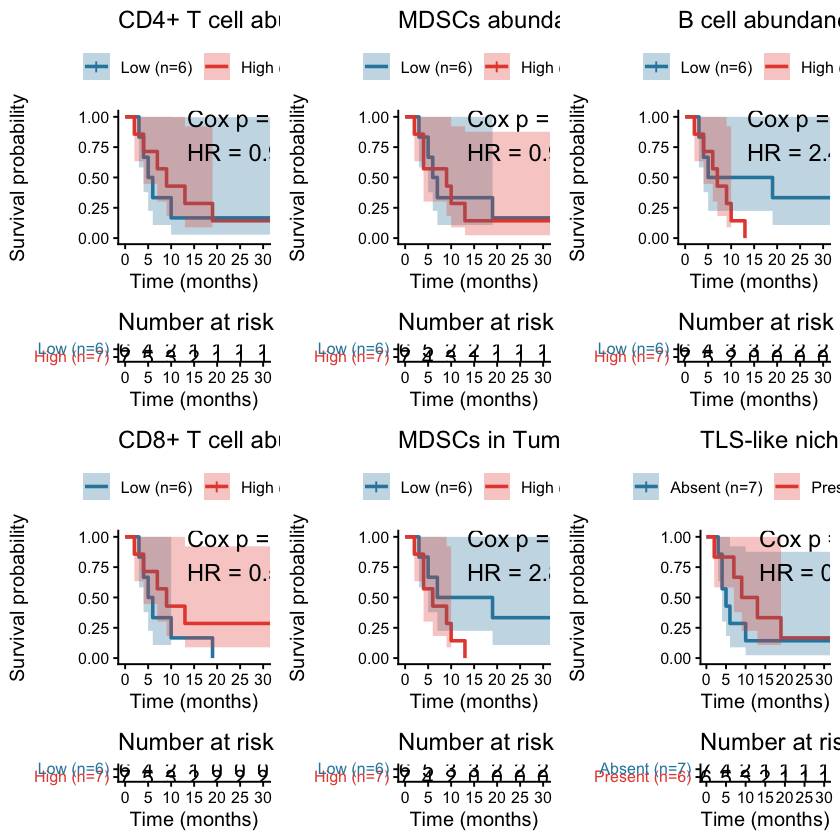

In [16]:
MIN_CELLS <- 10

# ---- build all panels ----
cd4 <- make_km(pct_patient(niches_df, "CD4+ T cells"),
               "CD4+ T cell abundance", split = "median")
cd8 <- make_km(pct_patient(niches_df, "CD8+ T cells"),
               "CD8+ T cell abundance", split = "median")
mdsc_tw <- make_km(pct_patient(niches_df, "MDSCs"),
                   "MDSCs abundance (tissue-wide)", split = "median")
mdsc_niche <- make_km(pct_patient(niches_df, "MDSCs", "Tumor_myeloid_enriched"),
                      "MDSCs in Tumor-myeloid niche", split = "median")
bcell <- make_km(pct_patient(niches_df, "B cells"),
                 "B cell abundance", split = "median")
tls <- make_km(niche_pct_patient(niches_df, "TLS_like"),
               "TLS-like niche presence", split = "presence", thresh = 1)

# ---- combine into one figure (3 cols x 2 rows) ----
combined <- arrange_ggsurvplots(
  list(cd4, cd8, mdsc_tw, mdsc_niche, bcell, tls),
  ncol = 3, nrow = 2,
  print = TRUE
)

ggsave(file.path(results_dir, "KM_nonsignificant_features_combined.pdf"),
       plot = combined, width = 18, height = 12, dpi = 300, bg = "white")